C:\Users\horie\machine_learning\lab2\data\car.png -> Predicted class: crash_helmet


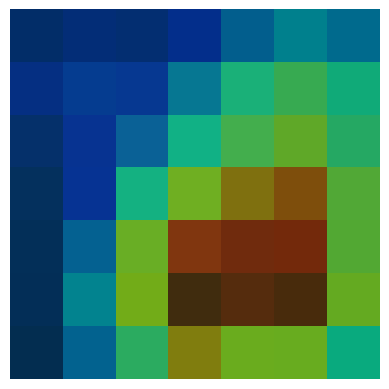

C:\Users\horie\machine_learning\lab2\data\dog.png -> Predicted class: Pembroke


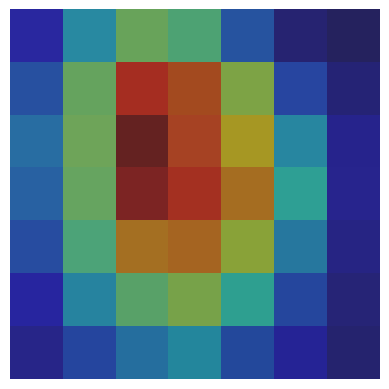

C:\Users\horie\machine_learning\lab2\data\Screenshot 2026-04-22 160121.png -> Predicted class: goldfish


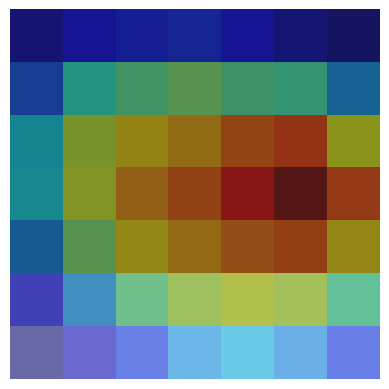

In [20]:
import torch
import torchvision.models as models
from PIL import Image
from torchvision import transforms
import json
import matplotlib.pyplot as plt
from torchcam.methods import SmoothGradCAMpp
import glob

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.eval()

# Preprocessing
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load ImageNet class index
json_path = r"C:\Users\horie\machine_learning\lab2\imagenet_class_index (2).json"
with open(json_path, "r") as f:
    idx_to_class = json.load(f)

# Attach CAM extractor
cam_extractor = SmoothGradCAMpp(model)

# Loop through all PNG images
img_paths = glob.glob(r"C:\Users\horie\machine_learning\lab2\data\*.png")

for img_path in img_paths:
    img = Image.open(img_path).convert("RGB")
    input_tensor = preprocess(img).unsqueeze(0)
    input_tensor.requires_grad_()   # <-- important fix

    # Prediction
    outputs = model(input_tensor)
    _, predicted_idx = outputs.max(1)

    predicted_class = idx_to_class[str(predicted_idx.item())][1]
    print(f"{img_path} -> Predicted class: {predicted_class}")

    # CAM visualization
    activation_map = cam_extractor(predicted_idx.item(), outputs)

    fig, ax = plt.subplots()
    ax.imshow(img)
    ax.imshow(activation_map[0].squeeze(0), cmap="jet", alpha=0.5)
    ax.axis("off")
    plt.show()
